# Week 3 — Function 3: Bayesian Optimisation (3D)

In [7]:
# Cell 2: Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [8]:
# Cell 3: Load data and inspect
# Function 3: Drug discovery — minimise adverse side effects (framed as maximise negative).
# Y values represent adverse reaction scores; we maximise to find the least harmful compounds.

X = np.load('../data/function_3/initial_inputs.npy')
Y = np.load('../data/function_3/initial_outputs.npy')

print(f'Input  shape : {X.shape}   (n_samples x n_dimensions)')
print(f'Output shape : {Y.shape}  (n_samples,)')
print()

# Sort descending by Y value
X_list = list(X)
Y_list = list(Y)
pairs = sorted(zip(Y_list, X_list), reverse=True)
Y_sorted = [p[0] for p in pairs]
X_sorted = [p[1] for p in pairs]

print('=' * 70)
print('  All observations (sorted descending by Y)')
print('=' * 70)
for i, (y_val, x_val) in enumerate(zip(Y_sorted, X_sorted)):
    marker = '  <-- best' if i == 0 else ''
    print(f'  [{i+1:2d}]  X = [{x_val[0]:.8f}, {x_val[1]:.8f}, {x_val[2]:.8f}]   Y = {y_val:+.6e}{marker}')
print('=' * 70)

best_Y = Y_sorted[0]
best_X = np.array(X_sorted[0])
print(f'\n  Best Y*  = {best_Y:.6e}')
print(f'  Best X*  = [{best_X[0]:.8f}, {best_X[1]:.8f}, {best_X[2]:.8f}]')

Input  shape : (15, 3)   (n_samples x n_dimensions)
Output shape : (15,)  (n_samples,)

  All observations (sorted descending by Y)
  [ 1]  X = [0.49258141, 0.61159319, 0.34017639]   Y = -3.483531e-02  <-- best
  [ 2]  X = [0.60009728, 0.72513573, 0.06608864]   Y = -3.637783e-02
  [ 3]  X = [0.22054934, 0.29782524, 0.34355534]   Y = -4.694741e-02
  [ 4]  X = [0.13462167, 0.21991724, 0.45820622]   Y = -4.800758e-02
  [ 5]  X = [0.96599485, 0.86111969, 0.56682913]   Y = -5.675837e-02
  [ 6]  X = [0.24211446, 0.64407427, 0.27243281]   Y = -8.796286e-02
  [ 7]  X = [0.17047699, 0.69703240, 0.14916943]   Y = -9.418956e-02
  [ 8]  X = [0.66601366, 0.67198515, 0.24629530]   Y = -1.059650e-01
  [ 9]  X = [0.34552327, 0.94135983, 0.26936348]   Y = -1.106209e-01
  [10]  X = [0.53490572, 0.39850092, 0.17338873]   Y = -1.114147e-01
  [11]  X = [0.17152521, 0.34391687, 0.24873720]   Y = -1.121222e-01
  [12]  X = [0.64550284, 0.39714294, 0.91977134]   Y = -1.138685e-01
  [13]  X = [0.04680895, 0.231

In [9]:
# Cell 4: Fit GP with log-transformed Y

# Log-transform to handle extreme scale differences across observations
# Y values are adverse reaction scores; log(|Y|) preserves ordering in log-space
Y_fit = np.log(np.abs(Y) + 1e-300)

# Fixed RBF kernel (course style — no ConstantKernel, no optimisation)
kernel = RBF(length_scale=0.1, length_scale_bounds='fixed')
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
gp.fit(X, Y_fit)

print('=' * 62)
print('  GP Fitting Results')
print('=' * 62)
print(f'  Kernel                   : {gp.kernel_}')
print(f'  Log-marginal-likelihood  : {gp.log_marginal_likelihood_value_:.4f}')
print()

# Sanity check: predict at best known point
pred_mean, pred_std = gp.predict(best_X.reshape(1, -1), return_std=True)
actual_log = np.log(np.abs(best_Y) + 1e-300)
print('  Sanity check at best known X*:')
print(f'    X*                     = [{best_X[0]:.6f}, {best_X[1]:.6f}, {best_X[2]:.6f}]')
print(f'    GP predicted mean      = {pred_mean[0]:.4f}  (log-space)')
print(f'    Actual log(|Y*|)       = {actual_log:.4f}  (log-space)')
print(f'    GP predicted std       = {pred_std[0]:.8f}')
print('=' * 62)

  GP Fitting Results
  Kernel                   : RBF(length_scale=0.1)
  Log-marginal-likelihood  : -53.1288

  Sanity check at best known X*:
    X*                     = [0.492581, 0.611593, 0.340176]
    GP predicted mean      = -3.3571  (log-space)
    Actual log(|Y*|)       = -3.3571  (log-space)
    GP predicted std       = 0.00001000


In [10]:
# Cell 5: UCB acquisition over 20x20x20 grid

# Build 20x20x20 meshgrid over [0, 1]^3
x1 = np.linspace(0, 1, 20)
x2 = np.linspace(0, 1, 20)
x3 = np.linspace(0, 1, 20)
XX1, XX2, XX3 = np.meshgrid(x1, x2, x3)
X_grid = np.column_stack([XX1.ravel(), XX2.ravel(), XX3.ravel()])  # shape (8000, 3)

# GP predictions across the full grid
post_mean, post_std = gp.predict(X_grid, return_std=True)

# UCB acquisition: mean + beta * std
beta = 2.5  #Higher beta = more exploration at early stage (Week 1, sparse data)
acquisition = post_mean + beta * post_std  # shape (8000,)

# Next query = grid point with highest UCB
best_idx = np.argmax(acquisition)
next_x   = X_grid[best_idx]
next_acq = acquisition[best_idx]

# Portal submission string
portal_string = f'{next_x[0]:.6f}-{next_x[1]:.6f}-{next_x[2]:.6f}'

print('=' * 62)
print('  UCB Acquisition  (beta = 2.5, 20x20x20 grid)')
print('=' * 62)
print(f'  Grid size            : {len(X_grid)} points (20x20x20)')
print(f'  Max UCB value        : {next_acq:.4f}')
print(f'  Next query point     : [{next_x[0]:.6f}, {next_x[1]:.6f}, {next_x[2]:.6f}]')
print()
print('  Portal submission string:')
print(f'  >>> {portal_string} <<<')
print('=' * 62)

  UCB Acquisition  (beta = 2.5, 20x20x20 grid)
  Grid size            : 8000 points (20x20x20)
  Max UCB value        : 2.5000
  Next query point     : [0.421053, 1.000000, 1.000000]

  Portal submission string:
  >>> 0.421053-1.000000-1.000000 <<<


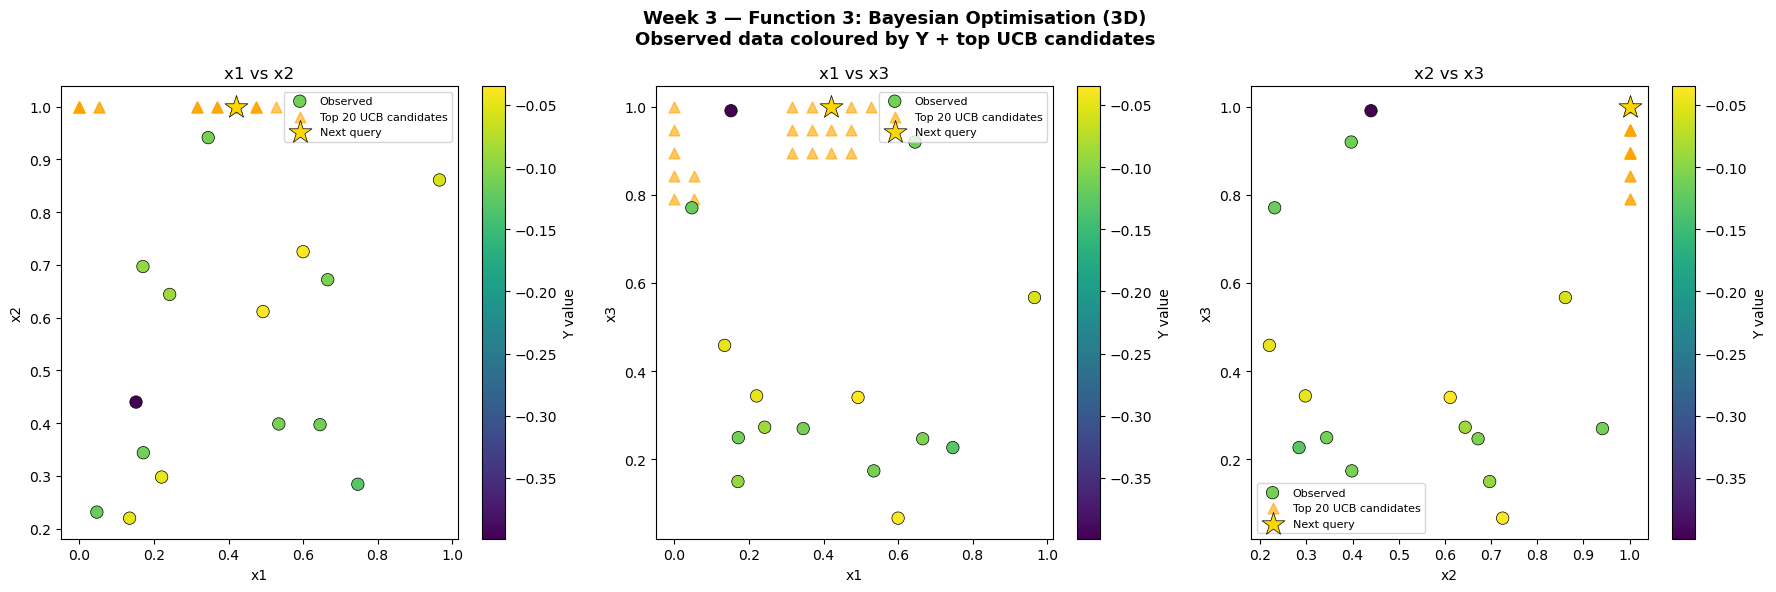

In [11]:
# Cell 6: Visualisation — scatter plots of observed data + top UCB candidates

# Top 20 candidates by UCB
top_idx = np.argsort(acquisition)[::-1][:20]
top_x   = X_grid[top_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

dim_labels = ['x1', 'x2', 'x3']
pairs_to_plot = [(0, 1), (0, 2), (1, 2)]

for ax, (d_a, d_b) in zip(axes, pairs_to_plot):
    sc = ax.scatter(X[:, d_a], X[:, d_b], c=Y, cmap='viridis', s=80,
                    edgecolors='k', linewidths=0.5, zorder=5, label='Observed')
    plt.colorbar(sc, ax=ax, label='Y value')
    ax.scatter(top_x[:, d_a], top_x[:, d_b], c='orange', marker='^', s=60,
               alpha=0.6, zorder=4, label='Top 20 UCB candidates')
    ax.scatter(next_x[d_a], next_x[d_b], c='gold', marker='*', s=300, zorder=6,
               edgecolors='black', linewidths=0.5, label='Next query')
    ax.set_xlabel(dim_labels[d_a])
    ax.set_ylabel(dim_labels[d_b])
    ax.set_title(f'{dim_labels[d_a]} vs {dim_labels[d_b]}')
    ax.legend(fontsize=8)

plt.suptitle('Week 3 — Function 3: Bayesian Optimisation (3D)\nObserved data coloured by Y + top UCB candidates',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Cell 7: Summary

print('=' * 62)
print('  SUMMARY — Bayesian Optimisation Results')
print('=' * 62)
print(f'  Function             : 3D Drug Discovery (adverse side effects)')
print(f'  Objective            : Maximise (maximise negative side effects score)')
print(f'  Kernel               : RBF(length_scale=0.1, fixed)')
print(f'  Acquisition function : UCB  (beta = 2.5)')
print(f'  Y transform          : log(|Y| + 1e-300)')
print(f'  Grid search          : 20x20x20 meshgrid (8,000 points)')
print()
print(f'  Current best X*      : [{best_X[0]:.6f}, {best_X[1]:.6f}, {best_X[2]:.6f}]')
print(f'  Current best Y*      : {best_Y:.6e}')
print()
print(f'  Next query point     : [{next_x[0]:.6f}, {next_x[1]:.6f}, {next_x[2]:.6f}]')
print()
print('  Portal submission string:')
print(f'  >>> {portal_string} <<<')
print('=' * 62)

  SUMMARY — Bayesian Optimisation Results
  Function             : 3D Drug Discovery (adverse side effects)
  Objective            : Maximise (maximise negative side effects score)
  Kernel               : RBF(length_scale=0.1, fixed)
  Acquisition function : UCB  (beta = 2.5)
  Y transform          : log(|Y| + 1e-300)
  Grid search          : 20x20x20 meshgrid (8,000 points)

  Current best X*      : [0.492581, 0.611593, 0.340176]
  Current best Y*      : -3.483531e-02

  Next query point     : [0.421053, 1.000000, 1.000000]

  Portal submission string:
  >>> 0.421053-1.000000-1.000000 <<<
